# Chapter 12: 성향점수 가중법 (Propensity Score Weighting, IPW)

## 학습 목표
이 장에서는 역확률 가중법(Inverse Probability Weighting, IPW)을 통한 성향점수 가중법을 배운다:

1. **IPW의 개념 및 원리**: 선택 편향을 보정하기 위해 가중치를 사용하는 방법
2. **ATE vs ATT 가중치**: 관심있는 효과에 따른 가중치 계산
3. **트리밍(Trimming)**: 극단 가중치를 처리하는 방법
4. **가중 OLS 회귀**: 가중치를 적용한 효과 추정
5. **PSM vs PSW**: 성향점수 짝짓기와 가중법의 비교
6. **LLM 기반 최적화**: 자동 가중치 타입 선택
7. **실데이터 적용**: observational_data_0.csv 분석

## 환경 설정

필요한 라이브러리를 설치하고 API 클라이언트를 초기화한다.

In [1]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# OpenAI API 클라이언트 설정
from openai import OpenAI
client = OpenAI()

# 시각화 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


## 1. 역확률 가중법(IPW) 개념

### 문제: 선택 편향
성향점수 짝짓기(PSM)와는 달리, **가중법**은 처치 받을 확률에 반비례하는 가중치를 사용해 선택 편향을 보정한다.

- **ATE 가중치**: $w_i = \frac{D_i}{e(X_i)} + \frac{1-D_i}{1-e(X_i)}$
- **ATT 가중치**: $w_i = D_i + (1-D_i) \cdot \frac{e(X_i)}{1-e(X_i)}$

가중치를 적용한 표본이 **무작위 할당된 표본처럼 행동**하게 된다.

In [2]:
# 선택 편향이 있는 시뮬레이션 데이터 생성
np.random.seed(42)
n = 1000

# 공변량 생성 (연령, 소득, 교육 수준)
age = np.random.normal(40, 15, n)
income = np.random.normal(50000, 20000, n)
education = np.random.normal(12, 4, n)

# 처치 결정: 공변량에 따라 처치 받을 확률이 달라짐 (선택 편향)
# 나이가 많고 소득이 높을수록 처치받을 확률이 높음
propensity_true = 1 / (1 + np.exp(-(-2 + 0.02 * age + 0.00003 * income + 0.05 * education)))
treatment = np.random.binomial(1, propensity_true, n)

# 결과(Y): 처치 효과 + 공변량 영향
# 진정한 처치 효과 = 5 (평균적으로 처치는 결과를 5만큼 증가시킴)
# 하지만 고소득 그룹이 더 높은 기초 결과를 가지고 있음
outcome = 100 + 5 * treatment + 0.001 * income + 0.05 * age + np.random.normal(0, 20, n)

# 데이터프레임 생성
df_sim = pd.DataFrame({
    'age': age,
    'income': income,
    'education': education,
    'treatment': treatment,
    'outcome': outcome,
    'propensity_true': propensity_true
})

print(f"시뮬레이션 데이터 생성 완료: {len(df_sim)} 관찰치")
print(f"처치 비율: {df_sim['treatment'].mean():.2%}")
print(f"\n첫 5행:")
print(df_sim.head())

시뮬레이션 데이터 생성 완료: 1000 관찰치
처치 비율: 72.10%

첫 5행:
         age        income  education  treatment     outcome  propensity_true
0  47.450712  77987.108732   9.299287          1  188.980899         0.852405
1  37.926035  68492.673658  11.421925          0  196.454536         0.799696
2  49.715328  51192.607398   8.830320          1  170.401690         0.725438
3  62.845448  37061.264446  10.768154          0  131.955260         0.712418
4  36.487699  63964.466272   4.425541          1  175.932831         0.704738


In [3]:
# 나이브 추정 (가중치 없음) vs 진정한 효과
# 처치받은 그룹과 처치받지 않은 그룹의 단순 평균 차이
naive_estimate = df_sim[df_sim['treatment'] == 1]['outcome'].mean() - df_sim[df_sim['treatment'] == 0]['outcome'].mean()

print(f"나이브 추정 (선택 편향 포함): {naive_estimate:.2f}")
print(f"진정한 처치 효과 (ATE): 5.00")
print(f"편향: {naive_estimate - 5:.2f}")
print(f"\n이는 처치받은 그룹의 높은 소득 때문에 결과가 더 높은 데서 비롯된 편향이다.")

나이브 추정 (선택 편향 포함): 14.39
진정한 처치 효과 (ATE): 5.00
편향: 9.39

이는 처치받은 그룹의 높은 소득 때문에 결과가 더 높은 데서 비롯된 편향이다.


## 2. 성향점수 추정

**성향점수** $e(X_i)$는 주어진 공변량 $X_i$에서 처치받을 확률이다.

로지스틱 회귀를 사용해 성향점수를 추정한다.

In [4]:
# 로지스틱 회귀로 성향점수 추정
def estimate_propensity_scores(df: pd.DataFrame, treatment: str, covariates: List[str]) -> np.ndarray:
    """로지스틱 회귀를 이용해 성향점수를 추정한다."""
    X = df[covariates]
    y = df[treatment]
    
    # 공변량 표준화
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 로지스틱 회귀
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)
    
    # 성향점수 계산 (극단값 방지: 0.01 ~ 0.99로 클리핑)
    propensity_scores = model.predict_proba(X_scaled)[:, 1]
    propensity_scores = np.clip(propensity_scores, 0.01, 0.99)
    
    return propensity_scores

# 성향점수 계산
covariates = ['age', 'income', 'education']
df_sim['propensity_score'] = estimate_propensity_scores(df_sim, 'treatment', covariates)

print("성향점수 추정 완료")
print(f"성향점수 범위: [{df_sim['propensity_score'].min():.3f}, {df_sim['propensity_score'].max():.3f}]")
print(f"성향점수 평균: {df_sim['propensity_score'].mean():.3f}")

성향점수 추정 완료
성향점수 범위: [0.258, 0.962]
성향점수 평균: 0.721


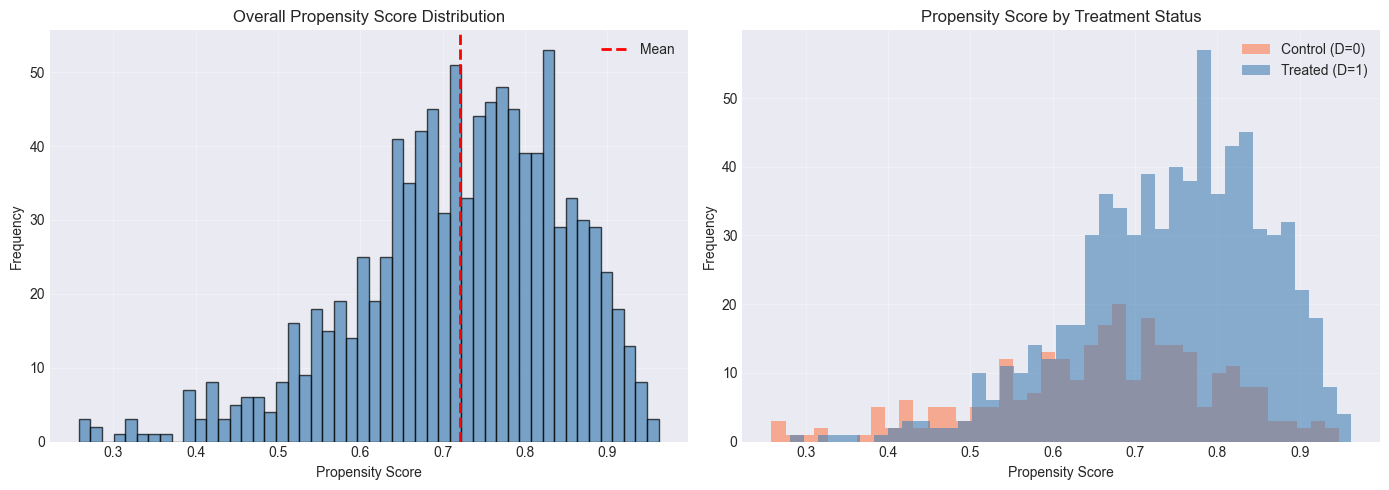


Propensity score statistics by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          279.0  0.661287  0.138465  0.258145  0.581264  0.676058  0.753979   
1          721.0  0.744229  0.115133  0.280684  0.672462  0.758878  0.828041   

                max  
treatment            
0          0.948170  
1          0.962434  


In [5]:
# Propensity score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall propensity score distribution
axes[0].hist(df_sim['propensity_score'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(df_sim['propensity_score'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Propensity Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Propensity score by treatment status
axes[1].hist(df_sim[df_sim['treatment'] == 0]['propensity_score'], bins=40, alpha=0.6, label='Control (D=0)', color='coral')
axes[1].hist(df_sim[df_sim['treatment'] == 1]['propensity_score'], bins=40, alpha=0.6, label='Treated (D=1)', color='steelblue')
axes[1].set_xlabel('Propensity Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Propensity Score by Treatment Status')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPropensity score statistics by treatment:')
print(df_sim.groupby('treatment')['propensity_score'].describe())


## 3. ATE vs ATT 가중치 계산

### ATE 가중치 (Average Treatment Effect)
전체 모집단에 대한 평균 처치 효과를 추정한다.
$$w_i^{ATE} = \frac{D_i}{e(X_i)} + \frac{1-D_i}{1-e(X_i)}$$

### ATT 가중치 (Average Treatment Effect on the Treated)
처치받은 그룹에 대한 평균 처치 효과를 추정한다.
$$w_i^{ATT} = D_i + (1-D_i) \cdot \frac{e(X_i)}{1-e(X_i)}$$

In [6]:
# ATE 및 ATT 가중치 계산
def calculate_weights(df: pd.DataFrame, treatment: str, propensity_col: str, weight_type: str = 'ATE') -> np.ndarray:
    """IPW 가중치를 계산한다.
    
    Args:
        df: 성향점수 포함 데이터프레임
        treatment: 처치 변수명
        propensity_col: 성향점수 컬럼명
        weight_type: 'ATE' 또는 'ATT'
    
    Returns:
        가중치 배열
    """
    e = df[propensity_col].values
    d = df[treatment].values
    
    if weight_type.upper() == 'ATE':
        # ATE: 1/e(X) for treated, 1/(1-e(X)) for control
        weights = np.where(d == 1, 1 / e, 1 / (1 - e))
    elif weight_type.upper() == 'ATT':
        # ATT: 1 for treated, e(X)/(1-e(X)) for control
        weights = np.where(d == 1, 1, e / (1 - e))
    else:
        raise ValueError(f"가중치 타입 지원 안 함: {weight_type}")
    
    return weights

# ATE 및 ATT 가중치 계산
df_sim['weight_ate'] = calculate_weights(df_sim, 'treatment', 'propensity_score', 'ATE')
df_sim['weight_att'] = calculate_weights(df_sim, 'treatment', 'propensity_score', 'ATT')

print("ATE 가중치 통계:")
print(df_sim['weight_ate'].describe())
print(f"\nATT 가중치 통계:")
print(df_sim['weight_att'].describe())

ATE 가중치 통계:
count    1000.000000
mean        2.014244
std         1.547942
min         1.039033
25%         1.248992
50%         1.438975
75%         2.092775
max        19.293897
Name: weight_ate, dtype: float64

ATT 가중치 통계:
count    1000.000000
mean        1.458514
std         1.363133
min         0.347972
25%         1.000000
50%         1.000000
75%         1.000000
max        18.293897
Name: weight_att, dtype: float64


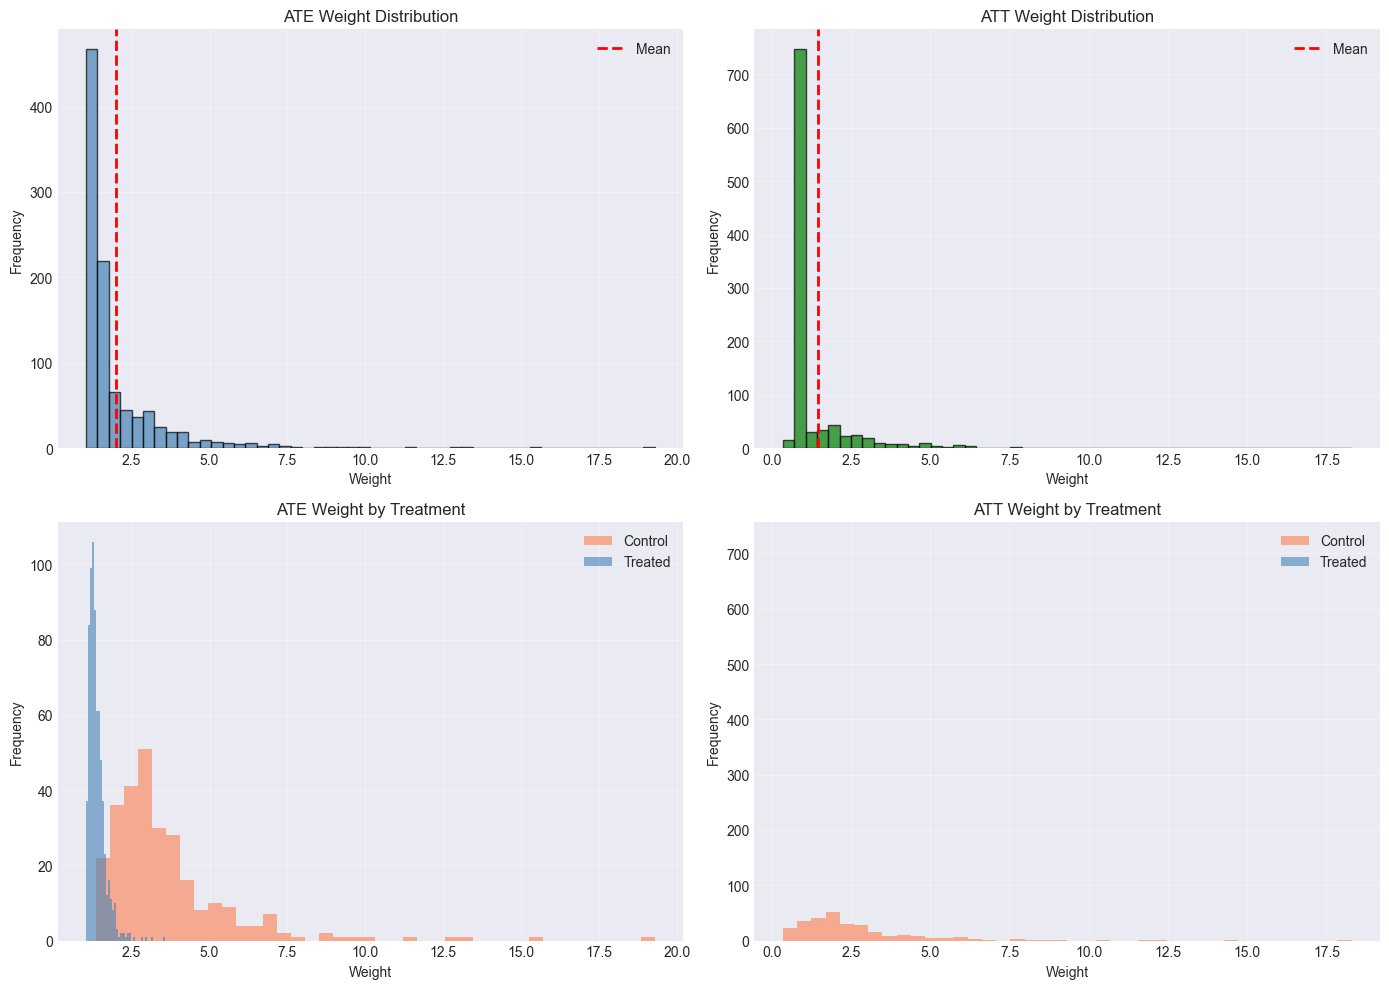


Extreme weight check (99th percentile):
ATE: 7.72
ATT: 6.72


In [7]:
# Weight distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ATE weight distribution
axes[0, 0].hist(df_sim['weight_ate'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(df_sim['weight_ate'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Weight')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('ATE Weight Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ATT weight distribution
axes[0, 1].hist(df_sim['weight_att'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(df_sim['weight_att'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Weight')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('ATT Weight Distribution')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ATE weight by treatment
axes[1, 0].hist(df_sim[df_sim['treatment'] == 0]['weight_ate'], bins=40, alpha=0.6, label='Control', color='coral')
axes[1, 0].hist(df_sim[df_sim['treatment'] == 1]['weight_ate'], bins=40, alpha=0.6, label='Treated', color='steelblue')
axes[1, 0].set_xlabel('Weight')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('ATE Weight by Treatment')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ATT weight by treatment
axes[1, 1].hist(df_sim[df_sim['treatment'] == 0]['weight_att'], bins=40, alpha=0.6, label='Control', color='coral')
axes[1, 1].hist(df_sim[df_sim['treatment'] == 1]['weight_att'], bins=40, alpha=0.6, label='Treated', color='steelblue')
axes[1, 1].set_xlabel('Weight')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('ATT Weight by Treatment')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nExtreme weight check (99th percentile):')
print(f'ATE: {np.percentile(df_sim["weight_ate"], 99):.2f}')
print(f'ATT: {np.percentile(df_sim["weight_att"], 99):.2f}')


## 4. IPW 추정량 계산

가중 평균 처치효과는 다음과 같이 계산된다:

$$\hat{\tau}_{IPW} = \frac{\sum w_i \cdot D_i \cdot Y_i}{\sum w_i \cdot D_i} - \frac{\sum w_i \cdot (1-D_i) \cdot Y_i}{\sum w_i \cdot (1-D_i)}$$

In [8]:
# IPW 추정량 계산 (Hajek/Horvitz-Thompson)
def estimate_ipw_effect(df: pd.DataFrame, outcome: str, treatment: str, weight_col: str) -> Tuple[float, float]:
    """IPW 추정량과 표준오차를 계산한다."""
    # 처치받은 그룹의 가중 평균 결과
    treated_mask = df[treatment] == 1
    treated_weighted_mean = (df.loc[treated_mask, weight_col] * df.loc[treated_mask, outcome]).sum() / \
                            df.loc[treated_mask, weight_col].sum()
    
    # 처치받지 않은 그룹의 가중 평균 결과
    control_mask = df[treatment] == 0
    control_weighted_mean = (df.loc[control_mask, weight_col] * df.loc[control_mask, outcome]).sum() / \
                            df.loc[control_mask, weight_col].sum()
    
    # 효과 추정
    effect = treated_weighted_mean - control_weighted_mean
    
    # 표준오차 (간단한 계산)
    treated_var = (df.loc[treated_mask, weight_col] * (df.loc[treated_mask, outcome] - treated_weighted_mean)**2).sum() / \
                  df.loc[treated_mask, weight_col].sum()
    control_var = (df.loc[control_mask, weight_col] * (df.loc[control_mask, outcome] - control_weighted_mean)**2).sum() / \
                  df.loc[control_mask, weight_col].sum()
    
    se = np.sqrt(treated_var / treated_mask.sum() + control_var / control_mask.sum())
    
    return effect, se

# ATE 및 ATT 효과 추정
ate_effect, ate_se = estimate_ipw_effect(df_sim, 'outcome', 'treatment', 'weight_ate')
att_effect, att_se = estimate_ipw_effect(df_sim, 'outcome', 'treatment', 'weight_att')

print("IPW 추정 결과")
print("="*50)
print(f"나이브 추정 (선택 편향): {naive_estimate:.2f}")
print(f"\nATE (평균 처치 효과): {ate_effect:.2f} (SE: {ate_se:.2f})")
print(f"95% CI: [{ate_effect - 1.96*ate_se:.2f}, {ate_effect + 1.96*ate_se:.2f}]")
print(f"\nATT (처치받은자 평균 효과): {att_effect:.2f} (SE: {att_se:.2f})")
print(f"95% CI: [{att_effect - 1.96*att_se:.2f}, {att_effect + 1.96*att_se:.2f}]")
print(f"\n진정한 효과: 5.00")

IPW 추정 결과
나이브 추정 (선택 편향): 14.39

ATE (평균 처치 효과): 2.42 (SE: 2.05)
95% CI: [-1.59, 6.43]

ATT (처치받은자 평균 효과): 1.63 (SE: 2.01)
95% CI: [-2.32, 5.57]

진정한 효과: 5.00


## 5. 트리밍(Trimming) - 극단 가중치 처리

극단적인 성향점수는 매우 큰 가중치를 생성할 수 있다. 이를 제거하거나 조정하는 **트리밍**을 사용한다.

In [9]:
# 트리밍 함수
def apply_trimming(df: pd.DataFrame, propensity_col: str, trim_threshold: float = 0.05) -> pd.DataFrame:
    """성향점수 백분위수를 기반으로 트리밍을 적용한다.
    
    Args:
        df: 성향점수 포함 데이터프레임
        propensity_col: 성향점수 컬럼명
        trim_threshold: 트리밍 백분위수 (0.05 = 상하 5% 트리밍)
    
    Returns:
        트리밍된 데이터프레임
    """
    min_ps = np.percentile(df[propensity_col], trim_threshold * 100)
    max_ps = np.percentile(df[propensity_col], (1 - trim_threshold) * 100)
    
    keep_mask = (df[propensity_col] >= min_ps) & (df[propensity_col] <= max_ps)
    n_removed = (~keep_mask).sum()
    
    print(f"트리밍: {n_removed}개 관찰치 제거 ({n_removed/len(df)*100:.1f}%)")
    print(f"성향점수 범위: [{min_ps:.3f}, {max_ps:.3f}]")
    
    return df[keep_mask].copy()

# 다양한 트리밍 수준 적용
trim_levels = [0, 0.01, 0.05, 0.1]
results_trim = []

for trim_level in trim_levels:
    if trim_level == 0:
        df_trimmed = df_sim.copy()
        print(f"\n트리밍 수준: {trim_level*100:.0f}% (트리밍 없음)")
    else:
        print(f"\n트리밍 수준: {trim_level*100:.0f}%")
        df_trimmed = apply_trimming(df_sim, 'propensity_score', trim_level)
    
    # ATE 효과 재계산
    ate_effect_trimmed, ate_se_trimmed = estimate_ipw_effect(df_trimmed, 'outcome', 'treatment', 'weight_ate')
    
    results_trim.append({
        'Trim Level': f"{trim_level*100:.0f}%",
        'Sample Size': len(df_trimmed),
        'ATE': f"{ate_effect_trimmed:.2f}",
        'SE': f"{ate_se_trimmed:.2f}",
        'CI Lower': f"{ate_effect_trimmed - 1.96*ate_se_trimmed:.2f}",
        'CI Upper': f"{ate_effect_trimmed + 1.96*ate_se_trimmed:.2f}"
    })

# 결과 표
results_trim_df = pd.DataFrame(results_trim)
print("\n\n트리밍 수준별 ATE 추정 결과:")
print(results_trim_df.to_string(index=False))


트리밍 수준: 0% (트리밍 없음)

트리밍 수준: 1%
트리밍: 20개 관찰치 제거 (2.0%)
성향점수 범위: [0.355, 0.935]

트리밍 수준: 5%
트리밍: 100개 관찰치 제거 (10.0%)
성향점수 범위: [0.485, 0.899]

트리밍 수준: 10%
트리밍: 200개 관찰치 제거 (20.0%)
성향점수 범위: [0.548, 0.872]


트리밍 수준별 ATE 추정 결과:
Trim Level  Sample Size  ATE   SE CI Lower CI Upper
        0%         1000 2.42 2.05    -1.59     6.43
        1%          980 2.94 2.00    -0.98     6.86
        5%          900 3.11 1.92    -0.65     6.86
       10%          800 3.04 1.97    -0.82     6.90


## 6. 가중 OLS 회귀

statsmodels의 `WLS` (Weighted Least Squares)를 사용하여 가중치를 반영한 회귀를 수행한다.

In [10]:
# 일반 OLS (가중치 없음)
X_ols = sm.add_constant(df_sim[['treatment', 'age', 'income', 'education']])
y_ols = df_sim['outcome']

ols_model = sm.OLS(y_ols, X_ols)
ols_results = ols_model.fit(cov_type='HC1')

print("일반 OLS 결과 (가중치 없음):")
print(ols_results.summary())
print(f"\n처치 효과 (OLS): {ols_results.params['treatment']:.2f}")

일반 OLS 결과 (가중치 없음):
                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     293.7
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          9.35e-167
Time:                        00:23:11   Log-Likelihood:                -4398.6
No. Observations:                1000   AIC:                             8807.
Df Residuals:                     995   BIC:                             8832.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.7710      3.109

In [11]:
# 가중 OLS (IPW, ATE)
wls_ate = sm.WLS(y_ols, X_ols, weights=df_sim['weight_ate'])
wls_ate_results = wls_ate.fit(cov_type='HC1')

print("가중 OLS 결과 (ATE 가중치):")
print(wls_ate_results.summary())
print(f"\n처치 효과 (IPW-ATE): {wls_ate_results.params['treatment']:.2f}")

가중 OLS 결과 (ATE 가중치):
                            WLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.540
Model:                            WLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     168.3
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          4.63e-110
Time:                        00:23:11   Log-Likelihood:                -4458.3
No. Observations:                1000   AIC:                             8927.
Df Residuals:                     995   BIC:                             8951.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.7302      3.90

In [12]:
# 가중 OLS (IPW, ATT)
wls_att = sm.WLS(y_ols, X_ols, weights=df_sim['weight_att'])
wls_att_results = wls_att.fit(cov_type='HC1')

print("가중 OLS 결과 (ATT 가중치):")
print(wls_att_results.summary())
print(f"\n처치 효과 (IPW-ATT): {wls_att_results.params['treatment']:.2f}")

가중 OLS 결과 (ATT 가중치):
                            WLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.532
Model:                            WLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     139.5
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.09e-94
Time:                        00:23:11   Log-Likelihood:                -4465.4
No. Observations:                1000   AIC:                             8941.
Df Residuals:                     995   BIC:                             8965.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.0997      4.37

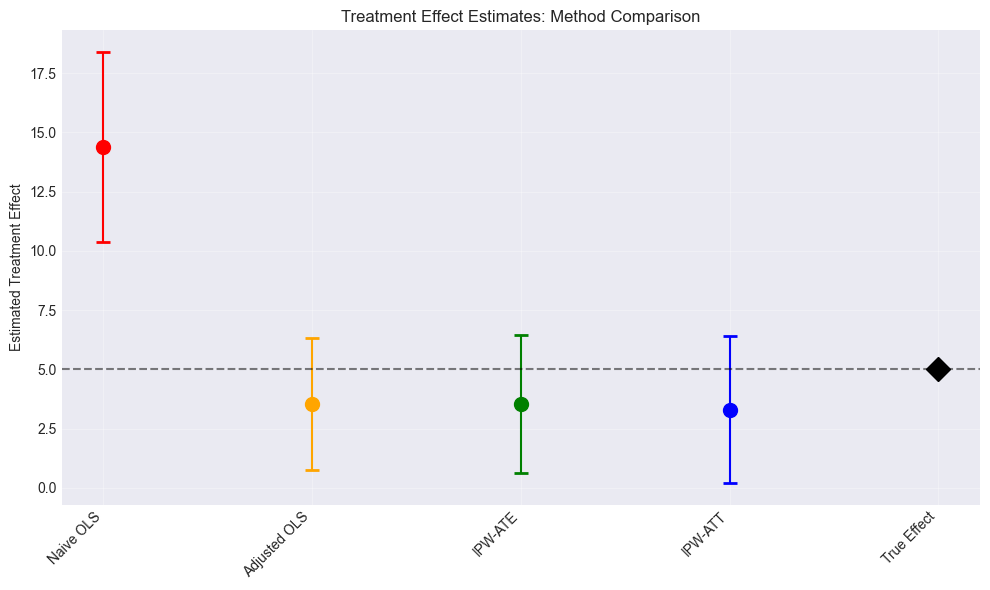

In [13]:
# Comparison of treatment effect estimates
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Naive OLS', 'Adjusted OLS', 'IPW-ATE', 'IPW-ATT', 'True Effect']
effects = [
    naive_estimate,
    ols_results.params['treatment'],
    wls_ate_results.params['treatment'],
    wls_att_results.params['treatment'],
    5.0
]
ses = [
    ate_se,
    ols_results.bse['treatment'],
    wls_ate_results.bse['treatment'],
    wls_att_results.bse['treatment'],
    0
]

x_pos = np.arange(len(methods))
colors = ['red', 'orange', 'green', 'blue', 'black']

for i, (method, effect, se, color) in enumerate(zip(methods, effects, ses, colors)):
    if se > 0:
        ax.errorbar(i, effect, yerr=1.96*se, fmt='o', markersize=10, color=color, capsize=5, capthick=2, label=method)
    else:
        ax.plot(i, effect, 'D', markersize=12, color=color, label=method)

ax.set_xticks(x_pos)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.axhline(y=5, color='black', linestyle='--', alpha=0.5, label='True Effect')
ax.set_ylabel('Estimated Treatment Effect')
ax.set_title('Treatment Effect Estimates: Method Comparison')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. PSM vs PSW 비교

성향점수 짝짓기(PSM)과 성향점수 가중법(PSW)의 장단점을 비교한다.

In [14]:
# PSM vs PSW 비교 표
comparison_data = {
    '특성': [
        '샘플 사용',
        '정보 손실',
        '가중치 극단값',
        '계산 복잡도',
        '해석 용이성',
        '표준 오차',
        '자동화 가능',
        '추천 상황'
    ],
    '성향점수 짝짓기 (PSM)': [
        '1:1 매칭만 사용 (샘플 손실)',
        '많음 (양쪽 모두)',
        '없음 (가중치 없음)',
        '낮음',
        '높음 (직관적)',
        '관대함',
        '어려움 (수동 확인)',
        '샘플 작을 때, 단순한 모델'
    ],
    '성향점수 가중법 (PSW)': [
        '모든 샘플 사용',
        '없음 (모든 정보 활용)',
        '있음 (트리밍 필요)',
        '중간',
        '보통 (해석 필요)',
        '더 엄격함',
        '쉬움 (자동 가능)',
        '큰 샘플, 극단값 적을 때'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n성향점수 짝짓기 vs 가중법 비교:")
print(comparison_df.to_string(index=False))


성향점수 짝짓기 vs 가중법 비교:
     특성     성향점수 짝짓기 (PSM) 성향점수 가중법 (PSW)
  샘플 사용 1:1 매칭만 사용 (샘플 손실)       모든 샘플 사용
  정보 손실         많음 (양쪽 모두)  없음 (모든 정보 활용)
가중치 극단값        없음 (가중치 없음)    있음 (트리밍 필요)
 계산 복잡도                 낮음             중간
 해석 용이성           높음 (직관적)     보통 (해석 필요)
  표준 오차                관대함          더 엄격함
 자동화 가능        어려움 (수동 확인)     쉬움 (자동 가능)
  추천 상황    샘플 작을 때, 단순한 모델 큰 샘플, 극단값 적을 때


In [15]:
# PSM 구현 (1:1 Nearest Neighbor Matching)
from sklearn.neighbors import NearestNeighbors

def psm_nearest_neighbor(df: pd.DataFrame, treatment: str, propensity_col: str, caliper: float = None):
    """Nearest neighbor 1:1 매칭을 수행한다."""
    treated_idx = df[df[treatment] == 1].index
    control_idx = df[df[treatment] == 0].index
    
    treated_ps = df.loc[treated_idx, propensity_col].values.reshape(-1, 1)
    control_ps = df.loc[control_idx, propensity_col].values.reshape(-1, 1)
    
    # Nearest neighbor 찾기
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control_ps)
    distances, indices = nn.kneighbors(treated_ps)
    
    # 매칭된 쌍
    matched_treated = treated_idx.tolist()
    matched_control = control_idx[indices.flatten()].tolist()
    
    # Caliper 적용
    if caliper:
        valid_pairs = distances.flatten() <= caliper
        matched_treated = [t for t, v in zip(matched_treated, valid_pairs) if v]
        matched_control = [c for c, v in zip(matched_control, valid_pairs) if v]
    
    matched_idx = matched_treated + matched_control
    return df.loc[matched_idx].copy()

# PSM 적용
df_psm = psm_nearest_neighbor(df_sim, 'treatment', 'propensity_score', caliper=0.1)
psm_effect = df_psm[df_psm['treatment'] == 1]['outcome'].mean() - df_psm[df_psm['treatment'] == 0]['outcome'].mean()

print(f"PSM 분석 결과:")
print(f"원본 샘플 크기: {len(df_sim)}")
print(f"매칭 후 샘플 크기: {len(df_psm)}")
print(f"PSM 추정 효과: {psm_effect:.2f}")

PSM 분석 결과:
원본 샘플 크기: 1000
매칭 후 샘플 크기: 1442
PSM 추정 효과: 3.31


In [16]:
# PSM vs PSW 결과 비교 표
psm_psw_comparison = pd.DataFrame({
    '방법': ['Naive', 'PSM (1:1 NN)', 'IPW-ATE', 'IPW-ATT', '진정한 효과'],
    '효과 추정': [f"{naive_estimate:.2f}", f"{psm_effect:.2f}", f"{ate_effect:.2f}", f"{att_effect:.2f}", "5.00"],
    '편향': [f"{naive_estimate - 5:.2f}", f"{psm_effect - 5:.2f}", f"{ate_effect - 5:.2f}", f"{att_effect - 5:.2f}", "0.00"],
    '샘플 크기': [f"{len(df_sim)}", f"{len(df_psm)}", f"{len(df_sim)}", f"{len(df_sim)}", "-"],
    '정보 손실': ["0%", f"{(1 - len(df_psm)/len(df_sim))*100:.1f}%", "0%", "0%", "-"]
})

print("\nPSM vs PSW 결과 비교:")
print(psm_psw_comparison.to_string(index=False))


PSM vs PSW 결과 비교:
          방법 효과 추정    편향 샘플 크기  정보 손실
       Naive 14.39  9.39  1000     0%
PSM (1:1 NN)  3.31 -1.69  1442 -44.2%
     IPW-ATE  2.42 -2.58  1000     0%
     IPW-ATT  1.63 -3.37  1000     0%
      진정한 효과  5.00  0.00     -      -


## 8. LLM 기반 가중치 타입 자동 선택

Claude AI를 사용하여 최적의 가중치 타입(ATE vs ATT)을 자동으로 선택한다.

In [17]:
from pydantic import BaseModel
from typing import Optional

class WeightTypeSelection(BaseModel):
    """LLM이 선택한 가중치 타입"""
    weight_type: str  # 'ATE' 또는 'ATT'
    reasoning: str    # 선택 이유
    trim_recommendation: Optional[str]  # 트리밍 권장사항

def determine_optimal_weight_type_llm(df: pd.DataFrame, treatment_col: str) -> WeightTypeSelection:
    """LLM을 사용해 최적의 가중치 타입을 결정한다."""

    # 데이터 특성 계산
    treated_pct = (df[treatment_col] == 1).mean()
    n_total = len(df)

    analysis_text = f"""
데이터 특성:
- 전체 샘플 크기: {n_total}
- 처치 그룹 비율: {treated_pct*100:.1f}%
- 처치받은 수: {(df[treatment_col] == 1).sum()}
- 처치받지 않은 수: {(df[treatment_col] == 0).sum()}

주어진 이 데이터에서 ATE(평균 처치 효과)와 ATT(처치받은자 평균 효과) 중 어느 것이
더 적합한지, 그리고 왜 그런지 선택해주세요.
또한 가중치 극단값 처리를 위해 트리밍이 필요한지 조언해주세요.
"""

    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": analysis_text}],
        response_format=WeightTypeSelection,
    )

    return response.choices[0].message.parsed

# LLM 호출
print("LLM을 통한 최적 가중치 타입 선택 중...\n")
weight_selection = determine_optimal_weight_type_llm(df_sim, 'treatment')

print(f"선택된 가중치 타입: {weight_selection.weight_type}")
print(f"\nLLM 분석:")
print(weight_selection.reasoning)
print(f"\n트리밍 권장: {weight_selection.trim_recommendation}")


LLM을 통한 최적 가중치 타입 선택 중...

선택된 가중치 타입: ATT (처치받은자 평균 효과)

LLM 분석:
이 데이터는 특정 처치 그룹(72.1%)과 비처치 그룹으로 나누어져 있습니다. ATE는 전체 표본의 평균 처치 효과를 측정하는 것이고, ATT는 처치를 받은 집단에서의 평균 처치 효과를 측정합니다. 이 경우, 처치받은 집단의 비율이 높기 때문에 ATT가 해당 데이터의 특징을 더 잘 반영하며, 처치의 영향을 실제로 경험한 집단의 평균 효과가 중요합니다.

트리밍 권장: None


## 9. 실데이터: observational_data_0.csv

실제 관측 데이터에 IPW 파이프라인을 적용한다.
- 처치 변수: `Smoker_Status` (0=비흡연, 1=흡연)
- 결과 변수: `Heart_Disease_Risk` (심장질환 위험 점수)
- 공변량: Age, BMI, Blood_Pressure, Cholesterol_Level, Alcohol_Consumption, Exercise_Regularly


In [18]:
# 실데이터 로드
data_path = './dataset/observational_data_0.csv'
df_real = pd.read_csv(data_path)

print(f'실데이터 로드 완료: {df_real.shape}')
print(f'\n컬럼명: {list(df_real.columns)}')
print(f'\n첫 5행:')
print(df_real.head())
print(f'\n기본 통계:')
print(df_real.describe())


실데이터 로드 완료: (392, 8)

컬럼명: ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Smoker_Status', 'Alcohol_Consumption', 'Exercise_Regularly', 'Heart_Disease_Risk']

첫 5행:
   Age  BMI  Blood_Pressure  Cholesterol_Level  Smoker_Status  \
0   31   15              15                 11              0   
1   22   22              12                  6              0   
2   27   26              13                 13              0   
3   31   19               8                 14              1   
4   21   13              10                 12              0   

   Alcohol_Consumption  Exercise_Regularly  Heart_Disease_Risk  
0                    0                   0           88.508183  
1                    1                   0           78.479554  
2                    1                   1           90.620856  
3                    0                   0           90.908963  
4                    1                   1           84.772530  

기본 통계:
              Age        BMI  Blood_Pre

In [19]:
# 실데이터에서 처치 및 결과 변수 확인
# 처치: Smoker_Status (0=비흡연, 1=흡연)
# 결과: Heart_Disease_Risk (심장질환 위험 점수)

treatment_col = 'Smoker_Status'
outcome_col = 'Heart_Disease_Risk'

print(f'처치 변수 ({treatment_col}): {df_real[treatment_col].unique()}')
print(f'처치 비율: {df_real[treatment_col].mean():.2%}')
print(f'\n결과 변수 ({outcome_col}) 범위: [{df_real[outcome_col].min():.2f}, {df_real[outcome_col].max():.2f}]')
print(f'결과 평균: {df_real[outcome_col].mean():.2f}')


처치 변수 (Smoker_Status): [0 1]
처치 비율: 39.03%

결과 변수 (Heart_Disease_Risk) 범위: [64.73, 110.64]
결과 평균: 92.57


In [20]:
# 실데이터에 IPW 적용 (완전한 파이프라인)
real_covariates = [col for col in df_real.columns
                   if col not in [treatment_col, outcome_col]]

print(f'공변량: {real_covariates}\n')

# 1. 성향점수 추정
df_real['propensity_score'] = estimate_propensity_scores(
    df_real, treatment_col, real_covariates)

# 2. 가중치 계산
df_real['weight_ate'] = calculate_weights(
    df_real, treatment_col, 'propensity_score', 'ATE')
df_real['weight_att'] = calculate_weights(
    df_real, treatment_col, 'propensity_score', 'ATT')

# 3. IPW 효과 추정
real_ate_effect, real_ate_se = estimate_ipw_effect(
    df_real, outcome_col, treatment_col, 'weight_ate')
real_att_effect, real_att_se = estimate_ipw_effect(
    df_real, outcome_col, treatment_col, 'weight_att')

print(f'실데이터 분석 결과:')
print(f'\n나이브 추정 (선택 편향): '
      f'{df_real[df_real[treatment_col] == 1][outcome_col].mean() - df_real[df_real[treatment_col] == 0][outcome_col].mean():.2f}')
print(f'\nIPW-ATE: {real_ate_effect:.2f} (SE: {real_ate_se:.2f})')
print(f'95% CI: [{real_ate_effect - 1.96*real_ate_se:.2f}, {real_ate_effect + 1.96*real_ate_se:.2f}]')
print(f'\nIPW-ATT: {real_att_effect:.2f} (SE: {real_att_se:.2f})')
print(f'95% CI: [{real_att_effect - 1.96*real_att_se:.2f}, {real_att_effect + 1.96*real_att_se:.2f}]')


공변량: ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'Alcohol_Consumption', 'Exercise_Regularly']

실데이터 분석 결과:

나이브 추정 (선택 편향): 1.26

IPW-ATE: 0.37 (SE: 0.77)
95% CI: [-1.13, 1.88]

IPW-ATT: 0.28 (SE: 0.75)
95% CI: [-1.20, 1.75]


In [21]:
# 가중 회귀 (실데이터)
X_real = sm.add_constant(df_real[[treatment_col] + real_covariates])
y_real = df_real[outcome_col]

# 일반 OLS
ols_real = sm.OLS(y_real, X_real).fit(cov_type='HC1')

# 가중 OLS (ATE)
wls_real_ate = sm.WLS(y_real, X_real, weights=df_real['weight_ate']).fit(cov_type='HC1')

# 가중 OLS (ATT)
wls_real_att = sm.WLS(y_real, X_real, weights=df_real['weight_att']).fit(cov_type='HC1')

print('실데이터 회귀 결과 비교:')
print(f'\nOLS (가중치 없음) 처치 효과: {ols_real.params[treatment_col]:.2f}')
print(f'IPW-ATE 가중 회귀 효과: {wls_real_ate.params[treatment_col]:.2f}')
print(f'IPW-ATT 가중 회귀 효과: {wls_real_att.params[treatment_col]:.2f}')


실데이터 회귀 결과 비교:

OLS (가중치 없음) 처치 효과: 0.36
IPW-ATE 가중 회귀 효과: 0.37
IPW-ATT 가중 회귀 효과: 0.32
